# Chapter 2 — Financial Data Structures
### AFML by Marcos López de Prado
Real Bitcoin Trade Data · March 2026

This notebook demonstrates every bar type from AFML Chapter 2, plus the CUSUM filter:

- **Section 2.3** — Standard Bars: Time, Tick, Volume, Dollar
- **Section 2.3.2** — Information-Driven Bars: Tick Imbalance, Volume Imbalance, Tick Run, Volume Run
- **Section 2.5** — CUSUM Filter: event-based sampling for ML feature matrices

## Setup — Imports

In [ ]:
import sys
import os

# Hardcode the project root — Jupyter's cwd depends on where the kernel was
# launched, not where this .ipynb lives, so cwd-based path math is unreliable
# across machines/launch methods. If you move this project, update this line.
AFML_ROOT = r'C:\ws\AFML'

ch02 = os.path.join(AFML_ROOT, 'ch02')
sys.path.insert(0, ch02)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import bars

print("Imports successful.")
print(f"ch02 path: {ch02}")

## Load Raw Tick Data

Each row is one individual trade — not a bar. Fields:
- **Price** — execution price in USD
- **Volume** — BTC traded
- **Timestamp** — microseconds since Unix epoch
- **IsBuyerMaker** — True if seller was aggressive (price went down), False if buyer was aggressive (price went up)

In [ ]:
base = ch02
data_path = os.path.join(base, 'input_data', 'BTCTUSD-trades-2026-03.csv')

raw = pd.read_csv(data_path, header=None,
                  names=['TradeID', 'Price', 'Volume', 'QuoteVolume',
                         'Timestamp', 'IsBuyerMaker', 'IsBestMatch'])

raw['Date']  = pd.to_datetime(raw['Timestamp'], unit='us')
raw['Label'] = raw['IsBuyerMaker'].apply(lambda x: -1 if x else 1)

df = raw[['Date', 'Price', 'Volume', 'Label']].copy()
df['Dollar'] = df['Price'] * df['Volume']
df = bars.delta(df)

print(f"Loaded {len(df):,} trades")
print(f"Date range: {df['Date'].iloc[0]} to {df['Date'].iloc[-1]}")
print(f"Price range: ${df['Price'].min():.2f} to ${df['Price'].max():.2f}")
df.head()

## Section 2.3 — Standard Bars

Standard bars close at **fixed thresholds** regardless of market conditions.
Each bar type samples the market differently:

| Bar Type | Closes every... | Best for... |
|----------|----------------|-------------|
| Time | Calendar day | Simple baselines |
| Tick | N trades | Equalising trade count |
| Volume | N BTC traded | Equalising economic activity |
| Dollar | $N traded | Most robust to price changes over time |

In [3]:
time_bar   = bars.time_bars(df, freq='D')
tick_bar   = bars.tick_bars(df, thresh=100)
volume_bar = bars.volume_bars(df, thresh=1.0)
dollar_bar = bars.dollar_bars(df, thresh=50000)

print(f"Time bars:   {len(time_bar):>6} bars  (1 per calendar day)")
print(f"Tick bars:   {len(tick_bar):>6} bars  (every 100 trades)")
print(f"Volume bars: {len(volume_bar):>6} bars  (every 1 BTC)")
print(f"Dollar bars: {len(dollar_bar):>6} bars  (every $50,000)")

Time bars:       31 bars  (1 per calendar day)
Tick bars:       92 bars  (every 100 trades)
Volume bars:     38 bars  (every 1 BTC)
Dollar bars:     53 bars  (every $50,000)


### Standard Bars Chart

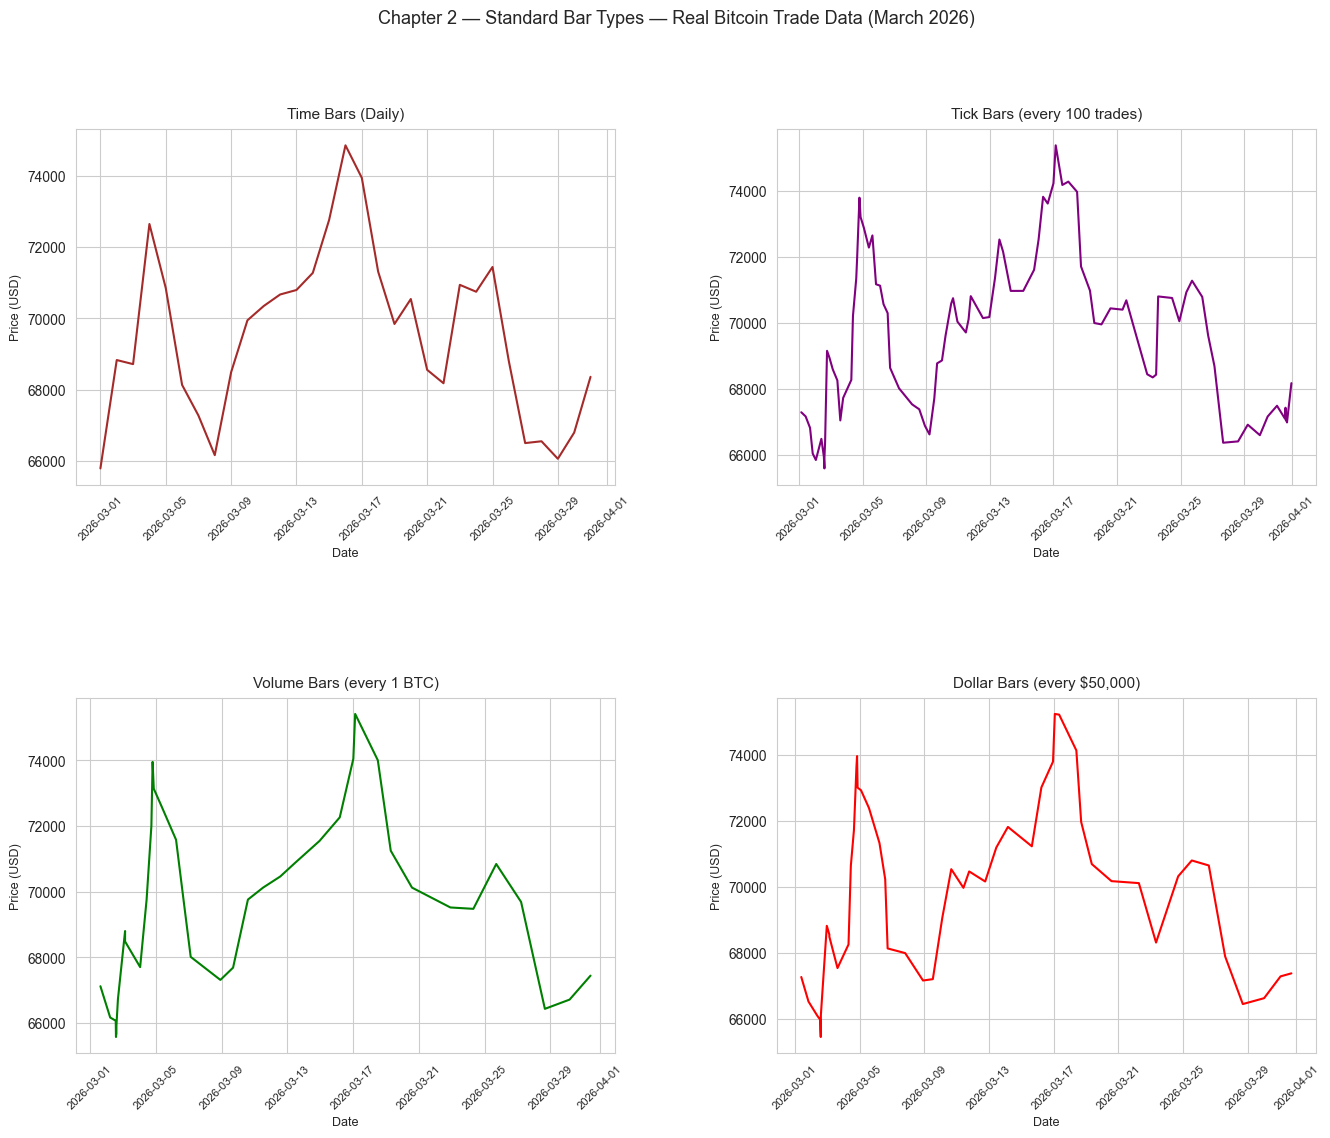

In [4]:
sns.set_style("whitegrid")
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle("Chapter 2 — Standard Bar Types — Real Bitcoin Trade Data (March 2026)",
              fontsize=13, y=0.98)

standard_plots = [
    (axes1[0,0], time_bar['Date'],   time_bar['Price'],   'brown',  "Time Bars (Daily)"),
    (axes1[0,1], tick_bar['Date'],   tick_bar['Vwap'],    'purple', "Tick Bars (every 100 trades)"),
    (axes1[1,0], volume_bar['Date'], volume_bar['Vwap'],  'green',  "Volume Bars (every 1 BTC)"),
    (axes1[1,1], dollar_bar['Date'], dollar_bar['Vwap'],  'red',    "Dollar Bars (every $50,000)"),
]

for ax, x, y, color, title in standard_plots:
    ax.plot(x, y, color=color)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel("Date", fontsize=9)
    ax.set_ylabel("Price (USD)", fontsize=9)
    ax.tick_params(axis='x', labelsize=8, rotation=45)

plt.subplots_adjust(hspace=0.6, wspace=0.3)
plt.show()

## Section 2.3.2 — Information-Driven Bars

Information-driven bars close based on **market conditions**, not fixed thresholds.
They sample more frequently during periods of informed trading and less frequently during quiet markets.

| Bar Type | Closes when... | Tracks... |
|----------|---------------|-----------|
| Tick Imbalance | Buy/sell count imbalance exceeds expectation | Direction |
| Volume Imbalance | Buy/sell volume imbalance exceeds expectation | Direction × size |
| Tick Run | Dominant-side tick streak exceeds expectation | Intensity |
| Volume Run | Dominant-side volume streak exceeds expectation | Intensity × size |

Each bar type adapts its threshold using EWMA of recent bar history — so the closing condition
automatically adjusts to current market conditions.

In [5]:
tick_imbalance_bar = bars.tick_imbalance_bars(df, expected_num_ticks_init=500)
imbalance_bar      = bars.volume_imbalance_bars(df, expected_num_ticks_init=50)
run_bar            = bars.tick_run_bars(df, expected_num_ticks_init=50)
volume_run_bar     = bars.volume_run_bars(df, expected_num_ticks_init=10)

print(f"Tick imbalance bars:   {len(tick_imbalance_bar):>6} bars")
print(f"Volume imbalance bars: {len(imbalance_bar):>6} bars")
print(f"Tick run bars:         {len(run_bar):>6} bars")
print(f"Volume run bars:       {len(volume_run_bar):>6} bars")
print()
print("Note: Volume run bars produce the fewest bars — they are the most selective,")
print("requiring both large volume AND sustained directional pressure to close.")

Tick imbalance bars:     8705 bars
Volume imbalance bars:   3265 bars
Tick run bars:            829 bars
Volume run bars:          103 bars

Note: Volume run bars produce the fewest bars — they are the most selective,
requiring both large volume AND sustained directional pressure to close.


### Information-Driven Bars Chart

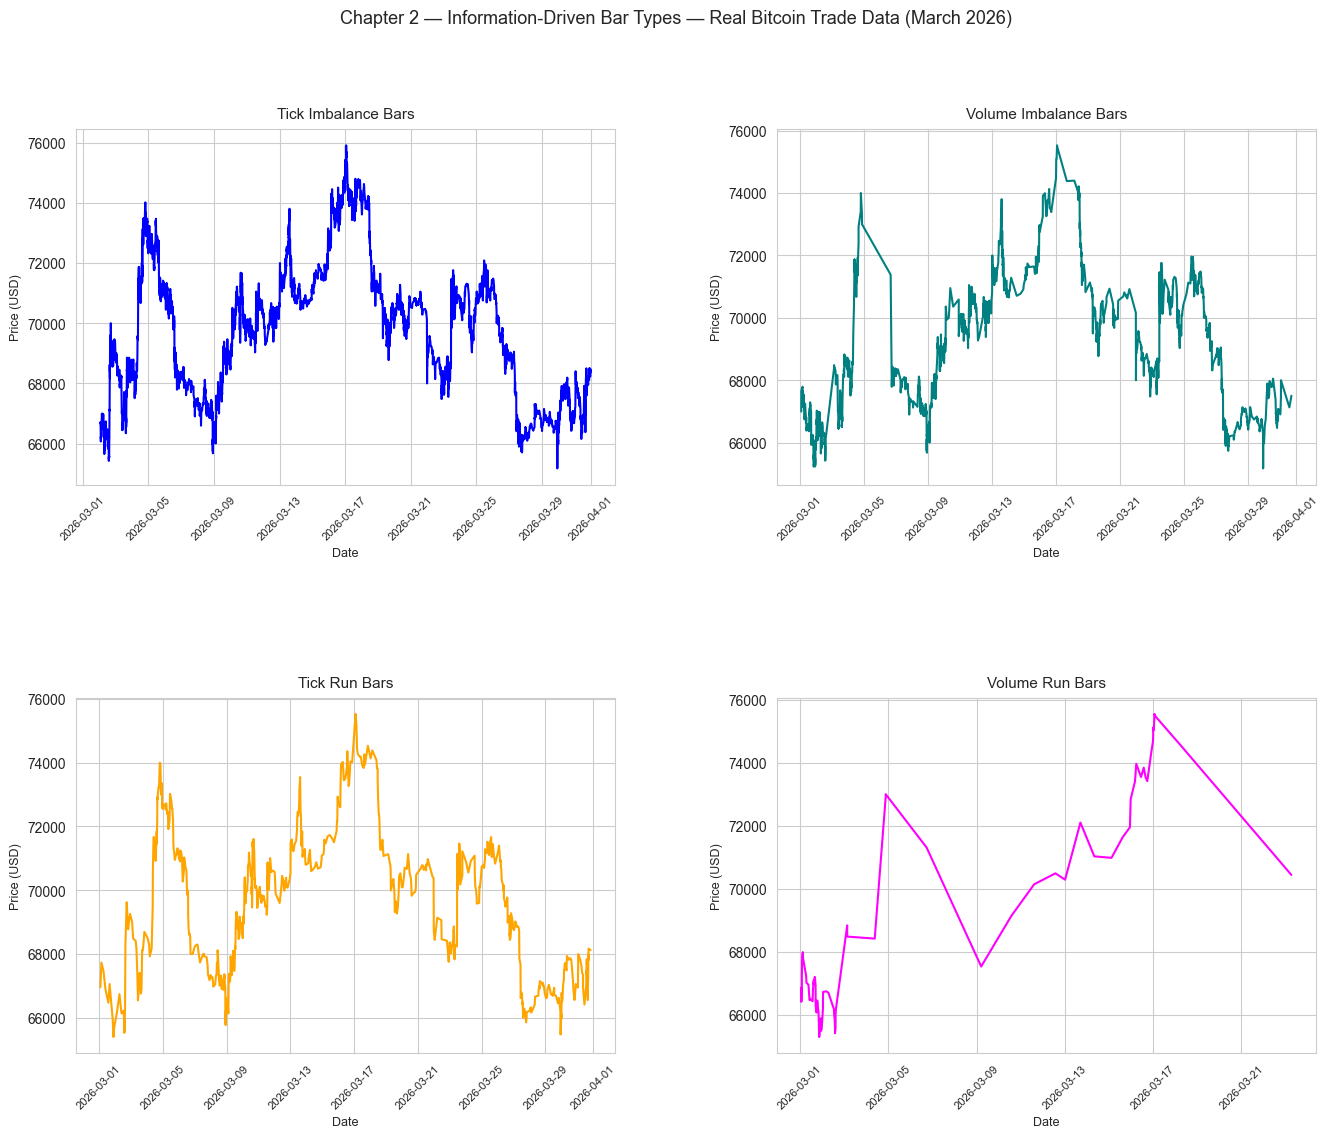

In [6]:
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Chapter 2 — Information-Driven Bar Types — Real Bitcoin Trade Data (March 2026)",
              fontsize=13, y=0.98)

info_plots = [
    (axes2[0,0], tick_imbalance_bar['Date'], tick_imbalance_bar['Close'], 'blue',    "Tick Imbalance Bars"),
    (axes2[0,1], imbalance_bar['Date'],      imbalance_bar['Vwap'],       'teal',    "Volume Imbalance Bars"),
    (axes2[1,0], run_bar['Date'],            run_bar['Vwap'],             'orange',  "Tick Run Bars"),
    (axes2[1,1], volume_run_bar['Date'],     volume_run_bar['Vwap'],      'magenta', "Volume Run Bars"),
]

for ax, x, y, color, title in info_plots:
    ax.plot(x, y, color=color)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel("Date", fontsize=9)
    ax.set_ylabel("Price (USD)", fontsize=9)
    ax.tick_params(axis='x', labelsize=8, rotation=45)

plt.subplots_adjust(hspace=0.6, wspace=0.3)
plt.show()

## Section 2.5 — CUSUM Filter

The CUSUM filter is not a bar type — it's a **sampling tool** for selecting which bars to include
as observations in a machine learning model.

It watches for when price has drifted at least **h dollars** from the level it was at when it last fired.
Only those dates get flagged as meaningful events worth including in the feature matrix.

**Why not just use every bar?**
- Most bars contain no meaningful information — the market is just noise
- Including every bar would oversample quiet periods and undersample active ones
- The CUSUM filter ensures each observation represents a genuine price move

**h = 500** means: only flag an event when cumulative price drift exceeds $500 since the last event.

In [7]:
h = 500
events = bars.cusum_filter(df, h)

print(f"CUSUM filter (h=${h}) fired {len(events)} events")
print(f"Out of {len(df):,} total ticks — sampled {len(events)/len(df)*100:.3f}% of ticks")
print(f"Average gap between events: {len(df) // len(events):,} ticks")
print()
print("These event dates would be used as the index into a feature matrix")
print("for training a machine learning model in Chapter 3.")
print()
print("First 10 event dates:")
for d in events[:10]:
    print(f"  {d}")

CUSUM filter (h=$500) fired 509 events
Out of 9,205 total ticks — sampled 5.530% of ticks
Average gap between events: 18 ticks

These event dates would be used as the index into a feature matrix
for training a machine learning model in Chapter 3.

First 10 event dates:
  2026-03-01 01:09:35.494195
  2026-03-01 01:47:51.751251
  2026-03-01 01:50:01.198785
  2026-03-01 02:02:21.303457
  2026-03-01 03:04:46.465087
  2026-03-01 04:16:38.009682
  2026-03-01 06:33:52.743991
  2026-03-01 07:35:29.555213
  2026-03-01 08:51:56.465389
  2026-03-01 13:20:58.002530
